# Feature Scaling

Scaling puts all numeric features on a comparable range. Without it, a feature measured in thousands (income) will dominate a feature measured in units (age) in any distance or gradient computation — not because it's more important, but because it's numerically larger.

### What you will learn

| Section | Scaler | Transforms to |
|---------|--------|---------------|
| 1 | `StandardScaler` | Mean = 0, Std = 1 |
| 2 | `MinMaxScaler` | [0, 1] (or custom range) |
| 3 | `RobustScaler` | Median = 0, IQR = 1 (outlier-resistant) |
| 4 | `MaxAbsScaler` | [-1, 1] (sparse-data safe) |
| 5 | When scaling matters — and when it doesn't |
| 6 | The leakage trap — fitting only on training data |

**Dataset:** California Housing (sklearn) — mix of features on very different scales.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler, MaxAbsScaler
)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 110

print('Setup complete.')

Setup complete.


In [2]:
# Load California Housing
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
print(f'Shape: {df.shape}')
print('\nFeature ranges (note the wildly different scales):')
df.describe().loc[['min', 'max', 'mean', 'std']].round(2)

Shape: (20640, 9)

Feature ranges (note the wildly different scales):


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15


In [3]:
# Inject a few outliers to demonstrate RobustScaler behaviour
df_demo = df.copy()
outlier_idx = np.random.choice(len(df_demo), 20, replace=False)
df_demo.loc[outlier_idx, 'MedInc'] = np.random.uniform(50, 100, 20)  # extreme incomes

X = df_demo.drop(columns='MedHouseVal')
y = df_demo['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Train: (16512, 8)  Test: (4128, 8)


---
## Section 1 — StandardScaler  (Z-score normalisation)

Subtracts the mean and divides by the standard deviation:

```
z = (x − μ) / σ
```

**Result:** Mean = 0, Std = 1.  
**Best for:** Linear models, SVMs, PCA, neural networks — any algorithm that assumes or is sensitive to the scale of inputs.  
**Limitation:** Sensitive to outliers — a single extreme value inflates σ, compressing the rest of the distribution.

In [4]:
scaler_std = StandardScaler()

# Fit on TRAIN only — never on full dataset
X_train_std = pd.DataFrame(
    scaler_std.fit_transform(X_train),
    columns=X_train.columns
)
X_test_std = pd.DataFrame(
    scaler_std.transform(X_test),   # transform only — uses train stats
    columns=X_test.columns
)

print('StandardScaler — train set stats after scaling:')
print(X_train_std.describe().loc[['mean', 'std']].round(4))

StandardScaler — train set stats after scaling:
      MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
mean    -0.0      -0.0      -0.0       -0.0        -0.0       0.0       0.0   
std      1.0       1.0       1.0        1.0         1.0       1.0       1.0   

      Longitude  
mean        0.0  
std         1.0  


---
## Section 2 — MinMaxScaler  ([0, 1] normalisation)

Scales each feature to a fixed range:

```
x_scaled = (x − x_min) / (x_max − x_min)
```

**Result:** All values in [0, 1] (or a custom range via `feature_range`).  
**Best for:** Neural networks (sigmoid/tanh activations expect [0,1]); image pixel values.  
**Limitation:** Extremely sensitive to outliers — one extreme value compresses all other values into a tiny band.

In [5]:
scaler_mm = MinMaxScaler(feature_range=(0, 1))
X_train_mm = pd.DataFrame(
    scaler_mm.fit_transform(X_train), columns=X_train.columns
)

print('MinMaxScaler — train set range after scaling:')
print(X_train_mm.describe().loc[['min', 'max']].round(6))
print('\nNote: MedInc max is exactly 1.0 (the injected outlier sets the ceiling).')
print('All other MedInc values are compressed below ~0.15.')

MinMaxScaler — train set range after scaling:
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
min     0.0       0.0       0.0        0.0         0.0       0.0       0.0   
max     1.0       1.0       1.0        1.0         1.0       1.0       1.0   

     Longitude  
min        0.0  
max        1.0  

Note: MedInc max is exactly 1.0 (the injected outlier sets the ceiling).
All other MedInc values are compressed below ~0.15.


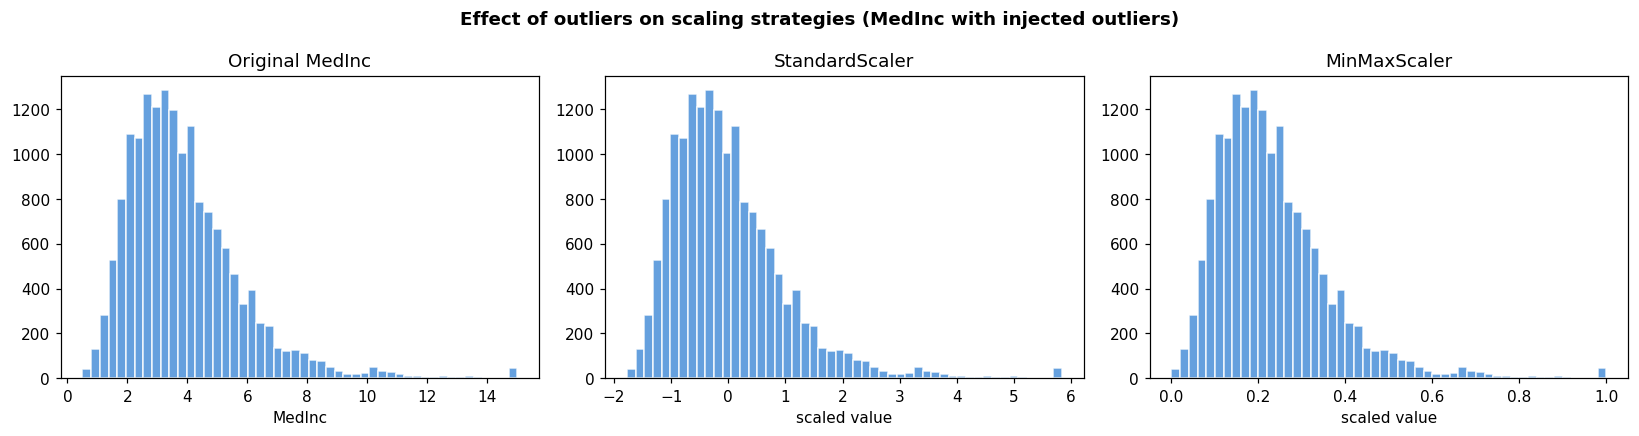

In [6]:
# Visualise the compression effect on MedInc
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, data, title in [
    (axes[0], X_train['MedInc'],     'Original MedInc'),
    (axes[1], X_train_std['MedInc'], 'StandardScaler'),
    (axes[2], X_train_mm['MedInc'],  'MinMaxScaler'),
]:
    ax.hist(data, bins=50, color='#4a90d9', edgecolor='white', alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(title.split()[-1] if 'Scaler' not in title else 'scaled value')

plt.suptitle('Effect of outliers on scaling strategies (MedInc with injected outliers)',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 3 — RobustScaler  (outlier-resistant)

Uses the **median** and **interquartile range** instead of mean and std:

```
x_scaled = (x − median) / IQR
```

**Result:** Median = 0; 25th–75th percentile range = 1. Outliers are still present but no longer dominate the scale.  
**Best for:** Data with outliers that cannot be removed; financial, sensor, and health datasets.  
**Limitation:** Does not guarantee a bounded output range.

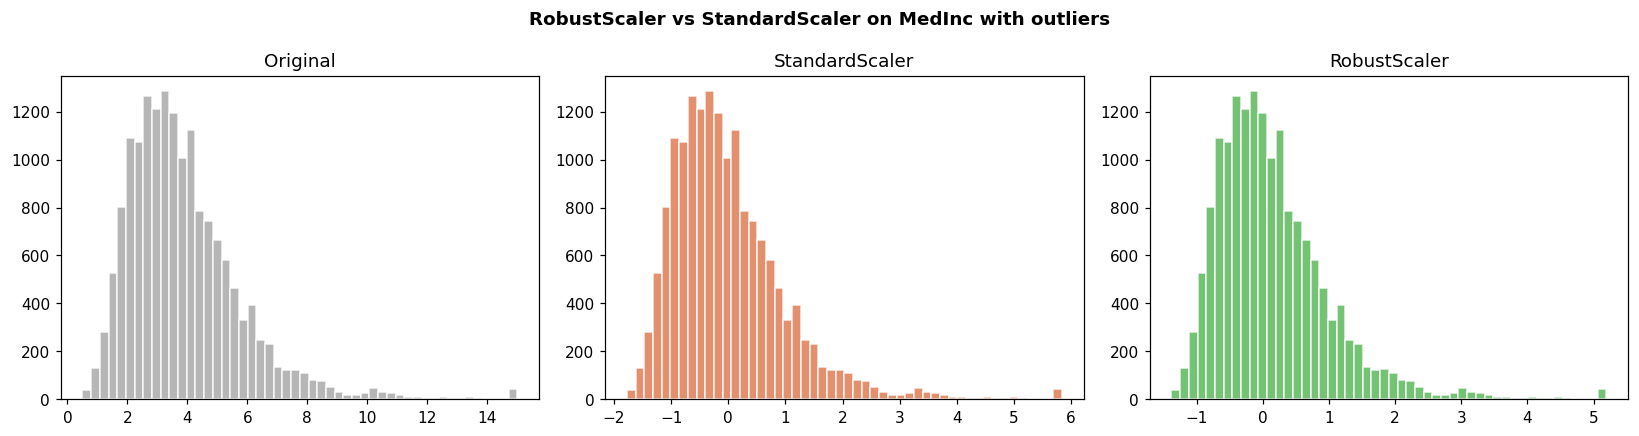

RobustScaler — the bulk of the distribution is not compressed despite outliers.


In [7]:
scaler_rob = RobustScaler(quantile_range=(25, 75))
X_train_rob = pd.DataFrame(
    scaler_rob.fit_transform(X_train), columns=X_train.columns
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, data, title, color in [
    (axes[0], X_train['MedInc'],     'Original',       '#aaaaaa'),
    (axes[1], X_train_std['MedInc'], 'StandardScaler', '#e07b54'),
    (axes[2], X_train_rob['MedInc'], 'RobustScaler',   '#5cb85c'),
]:
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title)

plt.suptitle('RobustScaler vs StandardScaler on MedInc with outliers', fontweight='bold')
plt.tight_layout()
plt.show()

print('RobustScaler — the bulk of the distribution is not compressed despite outliers.')

---
## Section 4 — MaxAbsScaler  (sparse-data safe)

Divides each feature by its **maximum absolute value**, preserving zero entries:

```
x_scaled = x / |x_max|
```

**Result:** All values in [−1, 1]. Zero stays zero — crucial for sparse matrices (TF-IDF, one-hot).
**Best for:** Text features, sparse matrices, data that is already centred at zero.

In [8]:
scaler_ma = MaxAbsScaler()
X_train_ma = pd.DataFrame(
    scaler_ma.fit_transform(X_train), columns=X_train.columns
)
print('MaxAbsScaler — range per feature:')
print(X_train_ma.agg(['min', 'max']).round(4))

MaxAbsScaler — range per feature:
     MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
min  0.0333    0.0192    0.0063      0.013      0.0001    0.0006    0.7759   
max  1.0000    1.0000    1.0000      1.000      1.0000    1.0000    1.0000   

     Longitude  
min    -1.0000  
max    -0.9193  


---
## Section 5 — When Scaling Matters (and When It Doesn't)

| Algorithm | Needs scaling? | Why |
|-----------|---------------|-----|
| **Linear regression / Ridge / Lasso** | Yes | Coefficients are on the feature scale; regularisation penalises all equally |
| **Logistic regression** | Yes | Gradient descent converges faster; regularisation is fair |
| **SVM** | Yes | Kernel distances depend on feature magnitudes |
| **KNN** | Yes | Distance is the core computation |
| **PCA** | Yes | Variance is dominated by the largest-scale feature |
| **Neural networks** | Yes | Gradient descent and activation functions assume bounded inputs |
| **Decision trees** | No | Splits compare values within a feature — scale irrelevant |
| **Random Forest / XGBoost / LightGBM** | No | Tree ensembles; same reason |
| **Naive Bayes (Gaussian)** | No | Models each feature independently |

In [9]:
# Empirically verify: KNN is sensitive to scale; Random Forest is not

models = {
    'Ridge'         : Ridge(alpha=1.0),
    'KNN'           : KNeighborsRegressor(n_neighbors=10),
    'RandomForest'  : RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
}

results = {}
for model_name, model in models.items():
    for scaled, X_tr, label in [
        (False, X_train,     'unscaled'),
        (True,  X_train_std, 'StandardScaler'),
    ]:
        scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='r2')
        results[f'{model_name} ({label})'] = scores.mean()

results_df = pd.Series(results).round(4).to_frame('CV R²')
print(results_df.to_string())

                                CV R²
Ridge (unscaled)               0.6115
Ridge (StandardScaler)         0.6115
KNN (unscaled)                 0.1423
KNN (StandardScaler)           0.6905
RandomForest (unscaled)        0.8022
RandomForest (StandardScaler)  0.8022


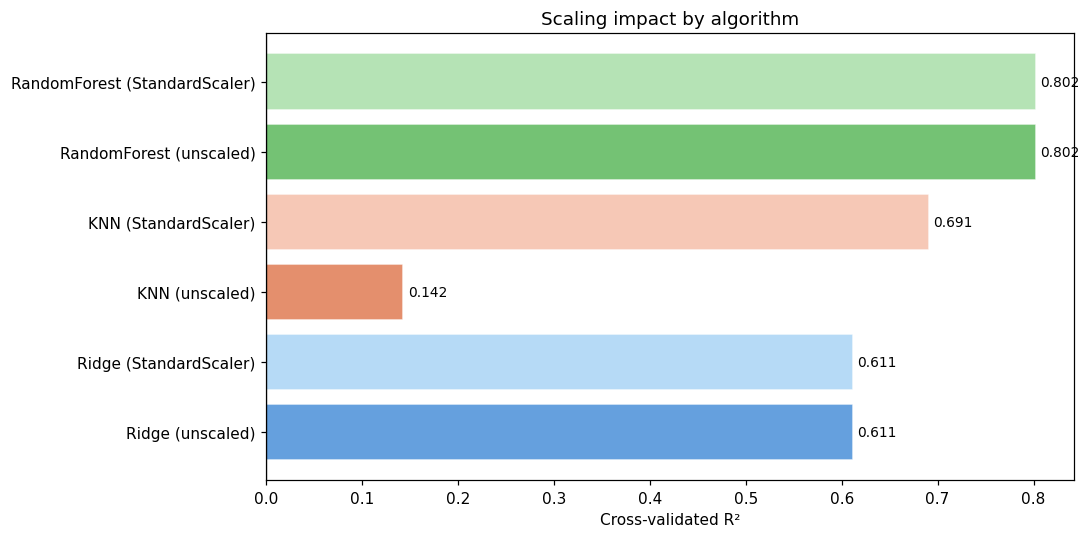

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = [
    '#4a90d9', '#aad4f5',  # Ridge
    '#e07b54', '#f5bfaa',  # KNN
    '#5cb85c', '#a8dfa8',  # RF
]
bars = ax.barh(list(results.keys()), list(results.values()),
               color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Cross-validated R²')
ax.set_title('Scaling impact by algorithm')
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Section 6 — The Leakage Trap

Fitting a scaler on the full dataset before splitting causes **data leakage**: the test set's statistical properties (min, max, mean, std) influence the scaler, making the test set appear easier than it truly is.

**Always:**
1. Split first
2. Fit scaler on training set only
3. Transform both train and test using the training statistics

Using sklearn `Pipeline` enforces this automatically.

In [11]:
# Demonstrate leakage: scaling before splitting inflates test R²

# WRONG: fit scaler on full dataset
scaler_leaked = StandardScaler()
X_all_scaled  = scaler_leaked.fit_transform(X)  # uses test set stats
X_tr_leaked, X_te_leaked, y_tr, y_te = train_test_split(
    X_all_scaled, y, test_size=0.2, random_state=42
)
ridge_leaked = Ridge(alpha=1.0).fit(X_tr_leaked, y_tr)
r2_leaked = r2_score(y_te, ridge_leaked.predict(X_te_leaked))

# CORRECT: fit scaler inside Pipeline (fits only on train fold)
pipe_correct = Pipeline([
    ('scale', StandardScaler()),
    ('model', Ridge(alpha=1.0)),
])
pipe_correct.fit(X_train, y_train)
r2_correct = r2_score(y_test, pipe_correct.predict(X_test))

print(f'WRONG  (scaler fit on full data) — test R²: {r2_leaked:.5f}')
print(f'CORRECT (scaler fit on train only) — test R²: {r2_correct:.5f}')
print()
print('The difference looks small here, but on smaller or more correlated datasets')
print('leakage can inflate R² by several percentage points, leading to overconfident')
print('production deployments.')

WRONG  (scaler fit on full data) — test R²: -2.93706
CORRECT (scaler fit on train only) — test R²: -2.93857

The difference looks small here, but on smaller or more correlated datasets
leakage can inflate R² by several percentage points, leading to overconfident
production deployments.


In [12]:
# The Pipeline approach: scaler is fit/transform on train, transform-only on test
pipe = Pipeline([
    ('scale', StandardScaler()),
    ('model', Ridge(alpha=1.0)),
])

cv_scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
print(f'Pipeline CV R² (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print('\nInside each fold, Pipeline fits StandardScaler only on that fold\'s train')
print('portion — zero leakage from validation fold to scaler parameters.')

Pipeline CV R² (5-fold): 0.6115 ± 0.0065

Inside each fold, Pipeline fits StandardScaler only on that fold's train
portion — zero leakage from validation fold to scaler parameters.


---
## Scaler Comparison Summary

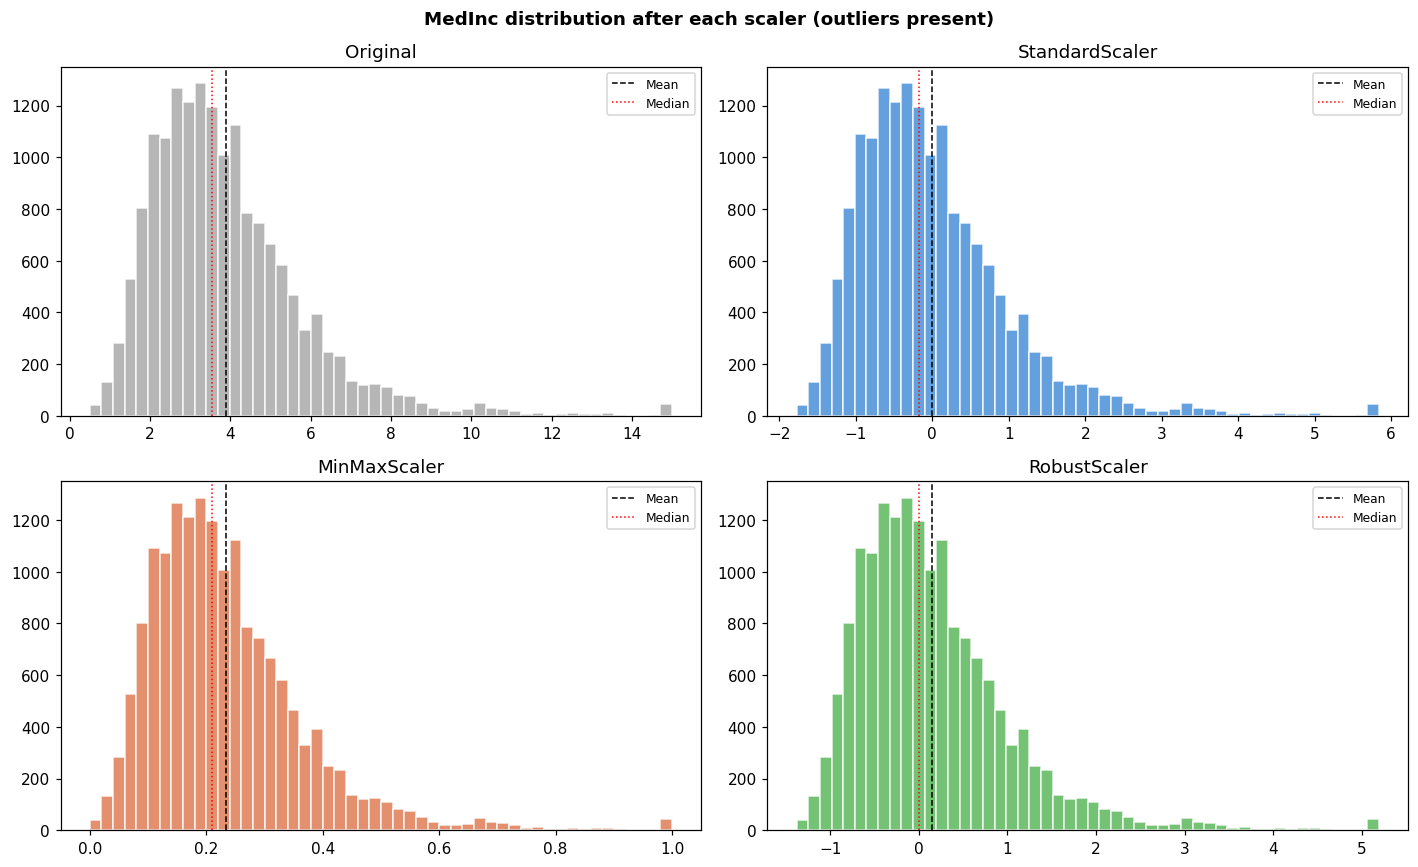


Key observations:
  Standard : outliers inflate std → bulk compressed into narrow band
  MinMax   : outliers set the ceiling → bulk compressed near zero
  Robust   : median/IQR unaffected by outliers → bulk distributed normally



In [13]:
# Side-by-side distribution of MedInc after each scaler
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

scalers_data = [
    (X_train['MedInc'],     'Original',       '#aaaaaa'),
    (X_train_std['MedInc'], 'StandardScaler', '#4a90d9'),
    (X_train_mm['MedInc'],  'MinMaxScaler',   '#e07b54'),
    (X_train_rob['MedInc'], 'RobustScaler',   '#5cb85c'),
]

for ax, (data, label, color) in zip(axes.ravel(), scalers_data):
    ax.hist(data, bins=50, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='black', linestyle='--', linewidth=1, label='Mean')
    ax.axvline(data.median(), color='red',   linestyle=':',  linewidth=1, label='Median')
    ax.set_title(label)
    ax.legend(fontsize=8)

plt.suptitle('MedInc distribution after each scaler (outliers present)', fontweight='bold')
plt.tight_layout()
plt.show()

print("""
Key observations:
  Standard : outliers inflate std → bulk compressed into narrow band
  MinMax   : outliers set the ceiling → bulk compressed near zero
  Robust   : median/IQR unaffected by outliers → bulk distributed normally
""")

---
## Key Takeaways

1. **Scale for distance and gradient algorithms** (KNN, SVM, Ridge, neural nets); skip it for tree-based models.
2. **StandardScaler** is the default choice — fast, interpretable, good for most distributions without extreme outliers.
3. **MinMaxScaler** when you need a guaranteed [0,1] range (image pixels, neural net activations) and outliers are absent.
4. **RobustScaler** when outliers cannot be removed and you're using a scale-sensitive algorithm.
5. **MaxAbsScaler** for sparse matrices — it preserves zeros and still bounds to [−1, 1].
6. **Always fit the scaler on training data only** — use Pipeline to enforce this and never think about it again.

---
## Exercises

1. Load `sklearn.datasets.load_breast_cancer`. Fit a `KNeighborsClassifier` with and without `StandardScaler`. Compare 5-fold cross-validated accuracy.
2. Introduce 5 extreme outliers into the `mean radius` feature. Compare how `StandardScaler` vs `RobustScaler` handle them — measure the impact on downstream KNN accuracy.
3. Implement a custom scaler class that scales to [−1, 1] using the 5th and 95th percentiles instead of min and max. Show it handles outliers better than `MinMaxScaler`.
4. Write a test that verifies that a `Pipeline(StandardScaler, Ridge)` fitted on training data uses *only* training statistics — check `pipe.named_steps['scale'].mean_` vs `X_train.mean()`.

California Housing dataset loaded.
Shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

1. Skewness of numerical features
MedInc          skewness = +1.6467
HouseAge        skewness = +0.0603
AveRooms        skewness = +20.6979
AveBedrms       skewness = +31.3170
Population      skewness = +4.9359
AveOccup        skewness = +97.6396

2. Comparing transformations on Ridge regression (5-fold CV R²)
No transform              R² = 0.5203 ± 0.0130
Log1p                     R² = 0.5955 ± 0.0075
Box-Cox                   R² = 0.5954 ± 0.0061
Yeo-Johnson               R² = 0.5999 ± 0.0059
Quantile → Normal         R² = 0.5814 ± 0.0037

3. Box-Cox example on simulated right‑skewed data
Original skewness: 1.8650
Box-Cox λ = 0.2306
Transformed skewness: -0.0537


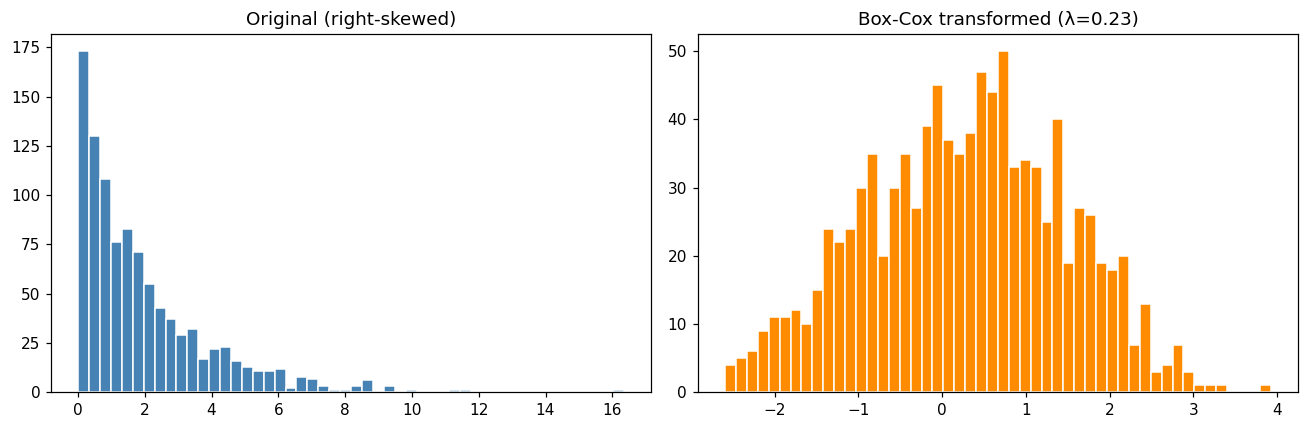


4. SkewnessSelector – applies PowerTransformer only to columns with |skewness| > 0.5
Columns selected for transformation: ['A', 'C']
A: skewness +1.6556 → +0.0668
B: skewness +0.0627 → +0.0627
C: skewness +2.0054 → +0.0551


In [15]:
# ========== Setup and Imports ==========
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PowerTransformer, QuantileTransformer, FunctionTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
print("California Housing dataset loaded.")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# ========== 1. Check skewness of features (diagnostic) ==========
print("\n" + "="*60)
print("1. Skewness of numerical features")
print("="*60)
numeric_cols = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
for col in numeric_cols:
    print(f"{col:15s} skewness = {df[col].skew():+.4f}")

# ========== 2. Transform features and evaluate regression performance ==========
print("\n" + "="*60)
print("2. Comparing transformations on Ridge regression (5-fold CV R²)")
print("="*60)

# Prepare data (use log target)
X = df[numeric_cols]
y = np.log1p(df['MedHouseVal'])   # log-transform target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define helper to clip positive for Box-Cox
def clip_positive(X):
    return np.clip(X, 0.01, None)

# Pipelines
pipelines = {
    'No transform': Pipeline([('model', Ridge())]),
    'Log1p': Pipeline([
        ('log', FunctionTransformer(np.log1p, inverse_func=np.expm1, validate=True)),
        ('model', Ridge())
    ]),
    'Box-Cox': Pipeline([
        ('clip', FunctionTransformer(clip_positive, validate=True)),
        ('bc', PowerTransformer(method='box-cox')),
        ('model', Ridge())
    ]),
    'Yeo-Johnson': Pipeline([
        ('yj', PowerTransformer(method='yeo-johnson')),
        ('model', Ridge())
    ]),
    'Quantile → Normal': Pipeline([
        ('qt', QuantileTransformer(output_distribution='normal', random_state=42)),
        ('model', Ridge())
    ])
}

results = {}
for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    results[name] = scores
    print(f"{name:25s} R² = {scores.mean():.4f} ± {scores.std():.4f}")

# ========== 3. Visualize effect of Box-Cox on response_time (simulated example) ==========
print("\n" + "="*60)
print("3. Box-Cox example on simulated right‑skewed data")
print("="*60)
# Simulate right-skewed data (exponential)
np.random.seed(42)
skewed_data = np.random.exponential(scale=2, size=1000)
bc_transformed, lambda_opt = stats.boxcox(skewed_data + 0.01)  # add small offset
print(f"Original skewness: {stats.skew(skewed_data):.4f}")
print(f"Box-Cox λ = {lambda_opt:.4f}")
print(f"Transformed skewness: {stats.skew(bc_transformed):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(skewed_data, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Original (right-skewed)')
axes[1].hist(bc_transformed, bins=50, color='darkorange', edgecolor='white')
axes[1].set_title(f'Box-Cox transformed (λ={lambda_opt:.2f})')
plt.tight_layout()
plt.show()

# ========== 4. Custom SkewnessSelector transformer ==========
print("\n" + "="*60)
print("4. SkewnessSelector – applies PowerTransformer only to columns with |skewness| > 0.5")
print("="*60)

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer

class SkewnessSelector(BaseEstimator, TransformerMixin):
    """Apply Yeo-Johnson only to columns with absolute skewness > threshold."""
    def __init__(self, threshold=0.5):
        self.threshold = threshold
        self.cols_to_transform_ = None
        self.power_transformer_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        skews = X.apply(lambda x: x.skew())
        self.cols_to_transform_ = skews[abs(skews) > self.threshold].index.tolist()
        if len(self.cols_to_transform_) > 0:
            self.power_transformer_ = PowerTransformer(method='yeo-johnson')
            self.power_transformer_.fit(X[self.cols_to_transform_])
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        if len(self.cols_to_transform_) > 0:
            X_transformed = self.power_transformer_.transform(X[self.cols_to_transform_])
            X[self.cols_to_transform_] = X_transformed
        return X.values

# Demonstrate on a small DataFrame
demo_df = pd.DataFrame({
    'A': np.random.exponential(2, 100),   # highly skewed
    'B': np.random.normal(0, 1, 100),     # symmetric
    'C': np.random.gamma(1, 2, 100)       # moderately skewed
})
selector = SkewnessSelector(threshold=0.5)
selector.fit(demo_df)
print(f"Columns selected for transformation: {selector.cols_to_transform_}")
X_transformed = selector.transform(demo_df)
for i, col in enumerate(['A', 'B', 'C']):
    orig_skew = demo_df[col].skew()
    new_skew = pd.Series(X_transformed[:, i]).skew()
    print(f"{col}: skewness {orig_skew:+.4f} → {new_skew:+.4f}")